In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
import scipy.linalg as la
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [3]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1)

print(np.array(btunes))
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))
print(ket1_1basis.kets)

[ 8.94590118  5.94607803  5.94607803  4.44616645 18.26678025 18.26678025]
[-0.5  0.5]
[KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Rb:58,P_1/2,1/2)]


In [4]:
b_index = 1

# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
        ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets:
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[3]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)
ket_tuples = []
for tuple0 in ket0_tuples:
    ket_tuples.append(tuple0)
for tuple1 in ket1_tuples: 
    ket_tuples.append(tuple1)
print(ket_tuples)


4
[(KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)), (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2)), (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))]


In [8]:
# setting target and resonant states
# ket_tuples = [tuple0, tuple1]


eff_system = pi.EffectiveSystemPair(ket_tuples)
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
# print(bs)

eff_h = eff_system.get_effective_hamiltonian(unit="MHz")
# eff_h -= np.eye(2) * eff_system.get_pair_energies("MHz")[1]

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\big hams\\'

if not os.path.exists(datapath):
    os.makedirs(datapath)
thetaList = np.linspace(0, 360, 100)
distance_default = 25

eff_h_dict = {}
diag_eff_h_dict = {}
rs = [5, 10, 15, 20, 25, 5000]
for r in rs:
    # for each b
    for mag in bs:
        # Hamiltonian dict
        eff_h_dict.update({f"mag{mag}sep{r}" : []})  
        
        eff_system.set_magnetic_field([0,0,mag], unit='G')
        eff_h_dict_elements = {'theta' : thetaList}
        pair_energy_pm = eff_system.get_pair_energies("MHz")[0]
        for i in range(len(ket_tuples)):
            for j in range(len(ket_tuples)):
                
                eff_h_dict_elements.update({f'{i}{j}' : []})
        print(len(eff_h_dict_elements))
        # for each theta
        for theta in thetaList:
            eff_system.set_distance(r, theta, "micrometer")
            
            H = eff_system.get_effective_hamiltonian(unit="MHz") - pair_energy_pm * np.eye(len(ket_tuples))
            for i in range(len(ket_tuples)):
                for j in range(len(ket_tuples)):
                    eff_h_dict_elements[f'{i}{j}'].append(H[i,j])
            
        pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'{n1_0}{n2_0} m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {mag}.csv', index=False)

65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65


In [9]:
print(len(ket_tuples))

8


In [ ]:
thetaList = np.linspace(0, 360, 100)
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
rs = [5, 10, 15, 20, 25, 5000]

H = {f'{mag}' : pd.read_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {mag}.csv') for mag in bs}
print(H)

matrix_lists = {f'{mag}' : [[[H[f'{mag}'][f'{i}{j}'][k] for i in range(len(ket_tuples))] for j in range(len(ket_tuples))] for k in range(len(H[f'{mag}']))] for mag in bs}
print(f'shape{np.shape(matrix_lists['0.0'])}')
eval_list = {f'{mag}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{mag}']] for mag in bs}
evec_list = {f'{mag}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{mag}']] for mag in bs}
Thetas = {f'{mag}' : H[f'{mag}']['theta'] for mag in bs}

{'0.0':          theta            00            01            02            03  \
0     0.000000 -4.768372e-07  0.000000e+00  0.000000e+00  0.000000e+00   
1     3.636364 -4.768372e-07  7.206384e-20  7.206384e-20 -4.579792e-21   
2     7.272727 -4.768372e-07  1.429682e-19  1.429682e-19 -1.824548e-20   
3    10.909091 -4.768372e-07  2.115721e-19  2.115721e-19 -4.077717e-20   
4    14.545455 -4.768372e-07  2.767717e-19  2.767717e-19 -7.181233e-20   
..         ...           ...           ...           ...           ...   
95  345.454545 -4.768372e-07 -2.767717e-19 -2.767717e-19 -7.181233e-20   
96  349.090909 -4.768372e-07 -2.115721e-19 -2.115721e-19 -4.077717e-20   
97  352.727273 -4.768372e-07 -1.429682e-19 -1.429682e-19 -1.824548e-20   
98  356.363636 -4.768372e-07 -7.206384e-20 -7.206384e-20 -4.579792e-21   
99  360.000000 -4.768372e-07  0.000000e+00  0.000000e+00  0.000000e+00   

              04            05            06            07            10  ...  \
0   1.889938e-08  0.00

In [11]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
2 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2))
3 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))
4 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2))
5 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2))
6 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,-1/2))
7 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))


0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
2 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2))
3 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))
4 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2))
5 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2))
6 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,-1/2))
7 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))
{'0.0': {'state0': [np.float64(-16.627892255783085), np.float64(-16.627892255783095), np.float64(-16.62789225578308), np.float64(-16.627892255783085), np.float64(-16.62789225578309), np.float64(-16.627892255783085), np.float64(-16.62789225578309), np.float64(-16.62789225578308), np.float64(-16.627892255783095), np.float64(-16.627892255783106), np.float64(-16.62789225578308), np.float64(-16.627892255783088), np.float64(-16.62789225578308), np.float64(-16.627892255783088), np.float64(-16.62789225578309), np.float64(-16.627892255783085), np.float64(

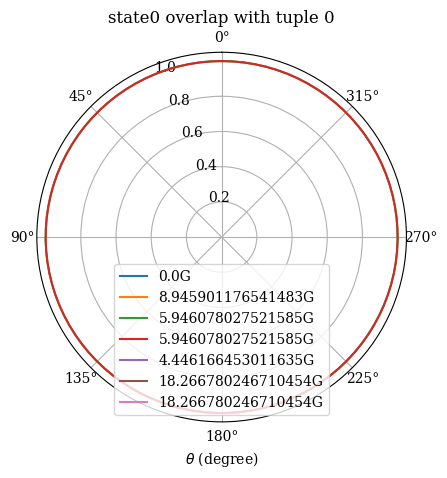

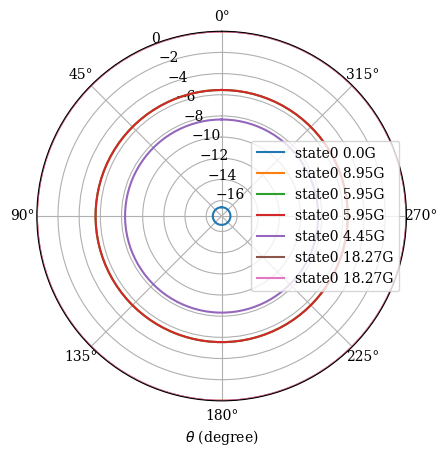

In [12]:
index=0

for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\Hams\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

Ediags = {f'{mag}' : {
    'state0' : [eval[index] for eval in eval_list[f'{mag}']]
} for mag in bs}

print(Ediags)
overlap = {f'{mag}' : [abs(np.dot([0,0,0,1,0,0,0,0], evec[index])) for evec in evec_list[f'{mag}']] for mag in bs}


# state0 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), overlap[f'{mag}'], label = f'{mag}G') 
ax.set_title('state0 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlap {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index0.png')
plt.legend()
plt.show() 


ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), np.array(Ediags[f'{mag}']['state0']), "-", label= f'state0 {round(mag, 2)}G')
plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
# ax.set_title(f'{tuple0[0]} {tuple0[1]} --> {tuple1[0]} {tuple1[1]}')
plt.savefig(figpath + f'\\eigenenergies {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index0.png')
plt.show()


# plt.savefig(figpath + f'\\eigenenergies {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index1.png')
# plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

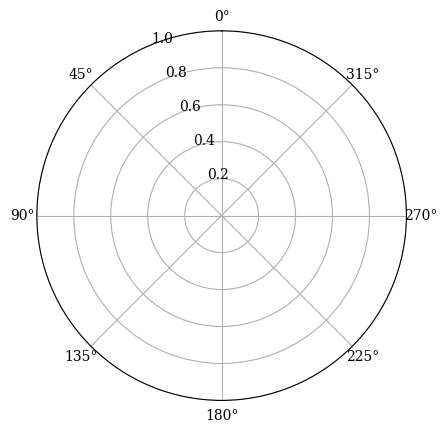

In [12]:
tuple0_index = 7
tuple1_index = 4

angData = {'theta' : thetaList}
for r in rs:
    for tuple0_index in range(len(ket_tuples)):
        angdata = {}
        Vdiag = {
            k: [eff_h[tuple0_index, tuple0_index] - pair_energy_pm for eff_h in eff_h_lists]
            for k, eff_h_lists in diag_eff_h_dict.items()
        }
        ax = plt.subplot(111, projection="polar")
        ax.set_theta_zero_location("N")
        for mag in bs:
            ax.plot(np.radians(thetaList[f'{mag}']), abs(np.array(Vdiag[f'{mag}'])), "-", label= f'{round(mag, 2)}G')
            # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
        plt.legend()

        ax.set_xlabel(r"$\theta$ (degree)")

        ax.set_title(f'{ket_tuples[tuple0_index][0]} {ket_tuples[tuple0_index][1]} sep {r}um')

        figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'

        if not os.path.exists(figpath + f'\\angular tunes\\big avg\\diag_d'):
            os.makedirs(figpath + f'\\angular tunes\\big avg\\diag_d')

        plt.savefig(figpath + f'\\angular tunes\\big avg\\diag_d\\{int(ket_tuples[tuple0_index][0].n)} {int(ket_tuples[tuple0_index][1].n)} mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}), sep {r}.png')
        plt.show()

        angData.update(Vdiag)

        datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\angular tunes\\big avg\\diag_d\\{int(ket_tuples[0][0].n)} {int(ket_tuples[0][1].n)}, sep {distance_default}'

        if not os.path.exists(datapath):
            os.makedirs(datapath)
            
        pd.DataFrame(angData).to_csv(datapath + f'\\mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}).csv')


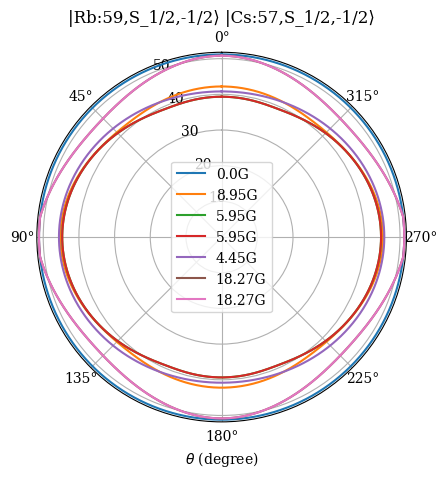

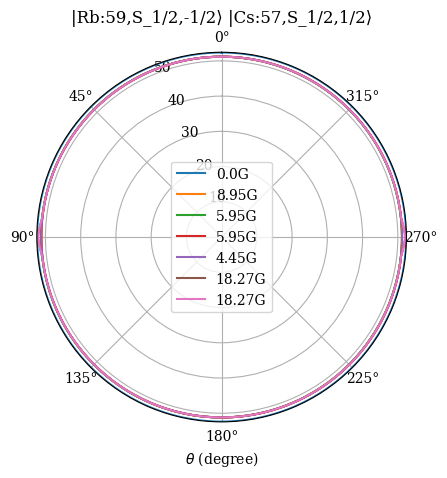

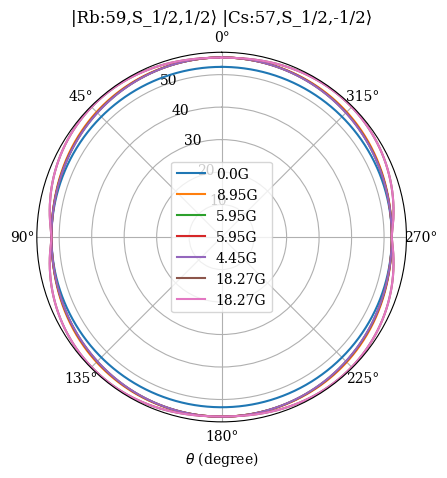

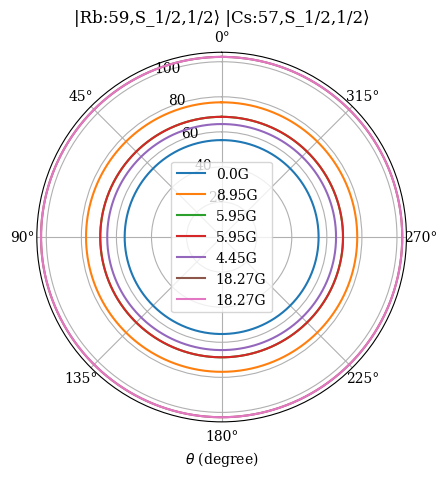

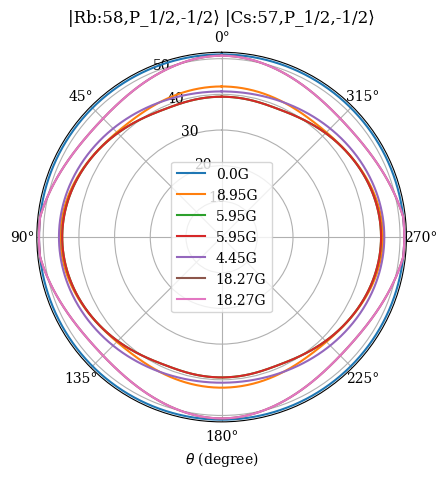

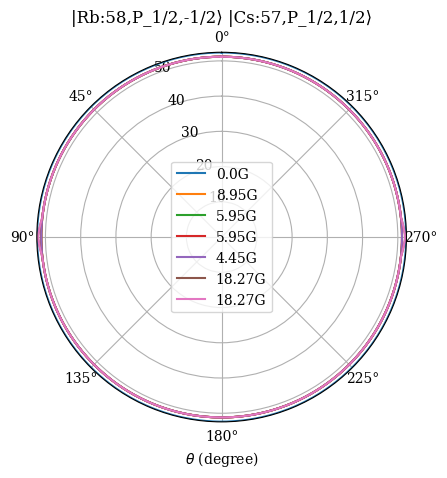

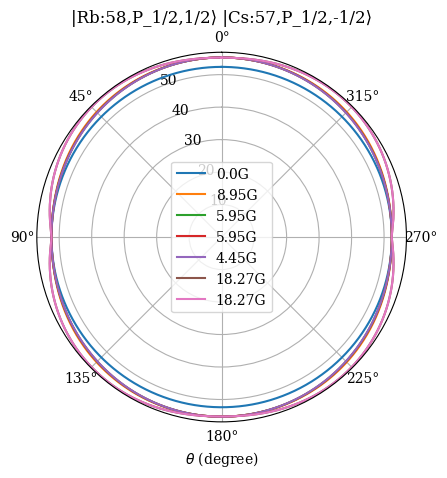

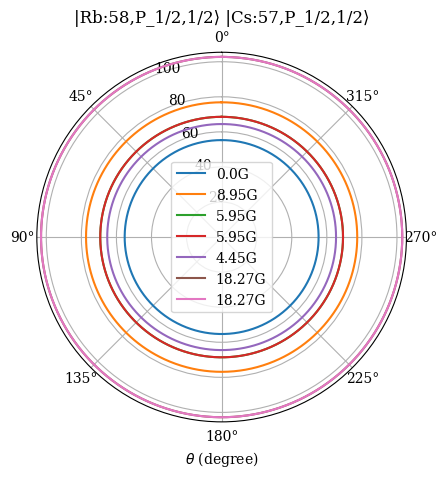

In [172]:
# reading file
for tuple0_index in range(len(ket_tuples)):
    Vdiag = pd.read_csv(datapath + f'\\mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}).csv')
    ax = plt.subplot(111, projection="polar")
    ax.set_theta_zero_location("N")
    for mag in bs:
        ax.plot(np.radians(thetaList), abs(np.array(Vdiag[f'{mag}'])), "-", label= f'{round(mag, 2)}G')
        # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
    plt.legend()

    ax.set_xlabel(r"$\theta$ (degree)")

    ax.set_title(f'{ket_tuples[tuple0_index][0]} {ket_tuples[tuple0_index][1]}')

    figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'

    if not os.path.exists(figpath + f'\\angular tunes\\big avg\\diag_d'):
        os.makedirs(figpath + f'\\angular tunes\\big avg\\diag_d')

    plt.savefig(figpath + f'\\angular tunes\\big avg\\diag_d\\{int(ket_tuples[tuple0_index][0].n)} {int(ket_tuples[tuple0_index][1].n)} mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}), {ket_tuples[tuple1_index][1].m}), sep {distance_default}.png')
    plt.show()

    angData.update(Vdiag)


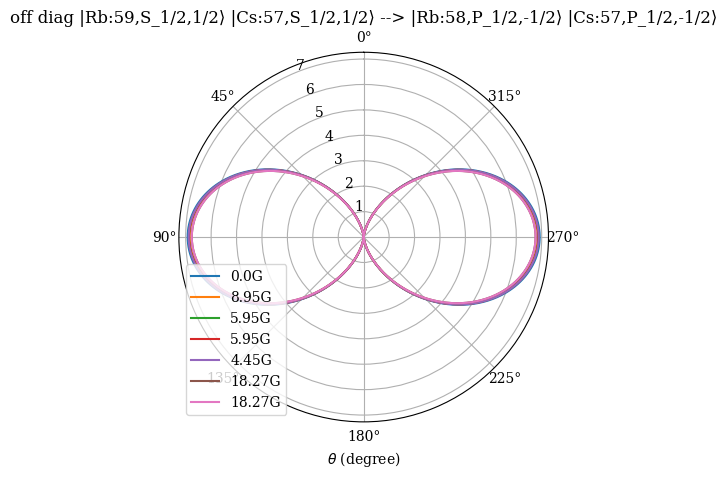

In [161]:
tuple0_index = 3
tuple1_index = 4
J00 = {k: [abs(eff_h[tuple0_index, tuple1_index]) for eff_h in eff_h_lists] for k, eff_h_lists in eff_h_dict.items()}
Vdiag = {
    k: [eff_h[tuple0_index, tuple0_index] - pair_energy_pm for eff_h in eff_h_lists]
    for k, eff_h_lists in eff_h_dict.items()
}
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(thetaList), abs(np.array(J00[f'{mag}'])), "-", label= f'{round(mag, 2)}G')
    # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
plt.legend()

ax.set_xlabel(r"$\theta$ (degree)")

ax.set_title(f'off diag {ket_tuples[tuple0_index][0]} {ket_tuples[tuple0_index][1]} --> {ket_tuples[tuple1_index][0]} {ket_tuples[tuple1_index][1]}')

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'

if not os.path.exists(figpath + f'\\angular tunes\\big avg'):
    os.makedirs(figpath + f'\\angular tunes\\big avg')

plt.savefig(figpath + f'\\angular tunes\\big avg\\off diag {n1_0} {n2_0} mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}) to mjs({ket_tuples[tuple1_index][0].m}, {ket_tuples[tuple1_index][1].m}), sep {distance_default}.png')
plt.show()

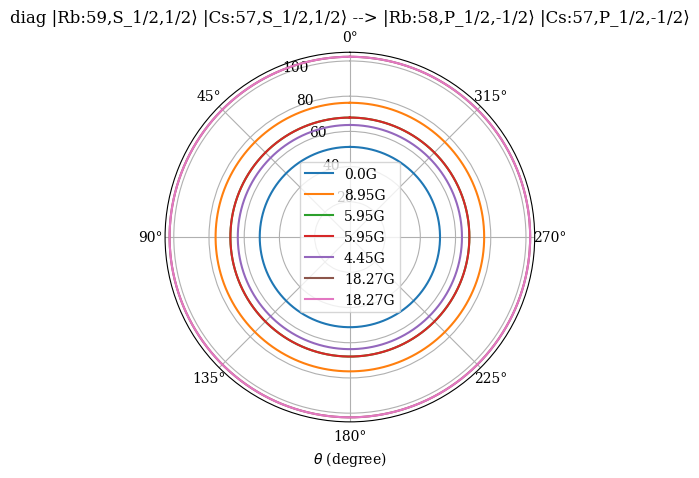

In [162]:
Vdiag = {
    k: [eff_h[tuple0_index, tuple0_index] - pair_energy_pm for eff_h in eff_h_lists]
    for k, eff_h_lists in eff_h_dict.items()
}
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(thetaList), abs(np.array(Vdiag[f'{mag}'])), "-", label= f'{round(mag, 2)}G')
    # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
plt.legend()

ax.set_xlabel(r"$\theta$ (degree)")

ax.set_title(f'diag {ket_tuples[tuple0_index][0]} {ket_tuples[tuple0_index][1]} --> {ket_tuples[tuple1_index][0]} {ket_tuples[tuple1_index][1]}')

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'

if not os.path.exists(figpath + f'\\angular tunes\\big avg'):
    os.makedirs(figpath + f'\\angular tunes\\big avg')

plt.savefig(figpath + f'\\angular tunes\\big avg\\diag {n1_0} {n2_0} mjs({ket_tuples[tuple0_index][0].m},{ket_tuples[tuple0_index][1].m}) to mjs({ket_tuples[tuple1_index][0].m}, {ket_tuples[tuple1_index][1].m}), sep {distance_default}.png')
plt.show()

KeyError: 'theta'

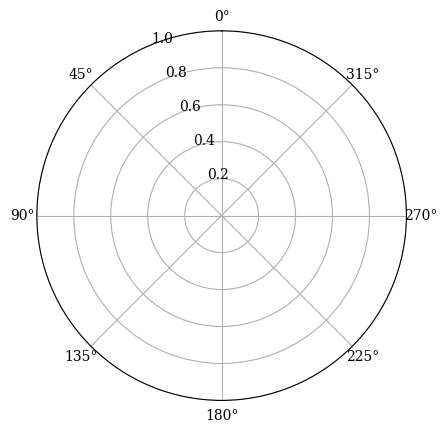

In [76]:
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'
plt.savefig(figpath + f'\\{n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), B {max(bs)}, sep {distance_default}.png')
if not os.path.exists(figpath):
    os.makedirs(figpath)
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")

ax.plot(np.radians(thetaList), Vdiag['theta'], "-", label= 'diag')
ax.plot(np.radians(thetaList), J00['theta'], "-", label = 'off diag')
plt.legend()

ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> {tuple1[0]} {tuple1[1]}')
# plt.savefig(figpath + f'\\{n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), B {b}, sep {distance_default}.png')